# Tarea para el Hogar 05 — versión Python

Adaptación de `z494_python.ipynb` a la lógica de `z495_GustavoPasquini.ipynb`. La carga del dataset y la generación de la clase ternaria permanecen sin cambios.

# Librerías

In [1]:
import os
import gc
import cudf
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
import optuna
from optuna.samplers import GPSampler
from optuna.trial import TrialState
from optuna.visualization import plot_param_importances, plot_contour,  plot_slice, plot_optimization_history




print('cuDF:', cudf.__version__)
print('GPU:', cp.cuda.runtime.getDeviceProperties(0)['name'].decode())

cuDF: 26.08.01
GPU: NVIDIA GeForce RTX 3090


In [2]:
import lightgbm as lgb
import yaml
import rdata

In [3]:
# dispongo la carpeta con funciones e importo ternara. 
from pathlib import Path
import sys

# Obtiene la ruta del directorio actual y sube un nivel (.parent)
raiz_proyecto = Path().resolve().parent

# Agrega la ruta al sistema si no está ya incluida
if str(raiz_proyecto) not in sys.path:
  sys.path.append(str(raiz_proyecto))




# URLs

In [4]:
BASE_URL = os.path.join(
    os.path.expanduser("~"),
    "code", "DMEyF", "dmeyf2026"
)

DATA_FOLDER = os.path.join(BASE_URL, 'entregas', 'dataset')
DATA_URL = os.path.join(BASE_URL, "DATA")
EXP_URL = os.path.join(DATA_URL, "EXP")

# DATA_TERNARIA_URL = os.path.join(DATA_FOLDER, 'competencia_01_ternaria.csv')
# DATA_LAGS_URL = os.path.join(DATA_FOLDER, 'c_01_tern_2_lags_O2.csv')

DATA_LAGS_URL = os.path.join(DATA_FOLDER, 'c_01_tern_2_lf_O2_k3_p6.csv')
DATA_LAGS_FRAC_URL = os.path.join(DATA_FOLDER, 'c_01_tern_2_lf_O2_k3_p6.csv')

# DATA_LAGS_URL = os.path.join(DATA_FOLDER, 'c_01_tern_2_lags.csv')
# DATA_LAGS_FRAC_URL = os.path.join(DATA_FOLDER, 'c_01_tern_2_lf_k6_p4.csv')

carpeta_man_val = os.path.join(BASE_URL, "ensembles", "man_val")
archivo_validaciones = os.path.join(carpeta_man_val, "validaciones_manuales.csv")

experiment_name = 'LAG-025'       # completar: nombre NUEVO de la primera BO
experimento_segunda = 'LAG-026'   # completar: nombre NUEVO de la segunda BO

if not all(isinstance(nombre, str) and nombre.strip()
           for nombre in (experiment_name, experimento_segunda)):
    raise ValueError("Completar experiment_name y experimento_segunda.")
if experiment_name == experimento_segunda:
    raise ValueError("Los nombres de los dos experimentos deben ser distintos.")

EXPERIMENT_URL = os.path.join(EXP_URL, experiment_name)

In [5]:
os.listdir(DATA_FOLDER)

['versiones_dataset_2.ipynb',
 'c_01_tern_2_lf_k6_p4.csv',
 'c_01_tern_2_lf_O2_k3_p6.csv',
 'competencia_01_ternaria_lf_k6_perdida4.csv',
 'c_01_tern_2_lags_O2.csv',
 'versiones_dataset_1.ipynb',
 'c_01_tern_2_lags.csv',
 'competencia_01_ternaria.csv',
 'competencia_01_crudo.csv',
 'competencia_01_ternaria_lags.csv',
 'c_01_tern_2.csv']

# Constantes

In [6]:
SEED = 230047

In [7]:
PARAM = {
    "experimento": experiment_name,
    "semilla_primigenia": SEED,
    "training_pct": 70,
    "train": [202103,202104],
    "train_final": [202103,202104],
    "future": [202106],
    "cortes": list(range(9_000, 15_001, 500)),
    "trainingstrategy": {"undersampling": 0.1},
    "hyperparametertuning": {
        "iteraciones": 200,
        "n_startup_trials": 50,
        "n_modelos_previos": 10,
        "xval_folds" : 3
    },
    "lgbm": {
        "param_fijos": {
            "boosting": "gbdt",
            "objective": "binary",
            # "metric": "auc",
            "metric": "average_precision",
            "feature_pre_filter": False,
            "first_metric_only": False,
            "boost_from_average": True,
            "force_row_wise": True,
            "deterministic": True,
            "verbosity": -100,
            "seed": SEED,
            "max_depth": -1,
            "min_gain_to_split": 0.0,
            "lambda_l1": 0.0,
            "lambda_l2": 0.0,
            "max_bin": 31,
            "bagging_fraction": 1.0,
            "pos_bagging_fraction": 1.0,
            "neg_bagging_fraction": 1.0,
            "is_unbalance": False,
            "scale_pos_weight": 1.0,
            "drop_rate": 0.1,
            "max_drop": 50,
            "skip_drop": 0.5,
            "extra_trees": False,
            "early_stopping": 0,
            "min_data_in_leaf": 0,
            "feature_fraction": 0.50,
            "feature_fraction_bynode": 0.20,
            # "learning_rate": 0.005,
  
        }
    },
    "out": {"lgbm": {}},
}

# Lectura del dataset

In [8]:
# cudf no pandas -> GPU
df = cudf.read_csv(
    DATA_LAGS_URL,
    dtype={'numero_de_cliente': 'int32', 'foto_mes': 'int32'}
)

In [9]:
df.head()

,numero_de_cliente,foto_mes,active_quarter,cliente_vip,internet,cliente_edad,cliente_antiguedad,mrentabilidad,mrentabilidad_annual,mcomisiones,...,Visa_madelantodolares_delta_lag_pond2,Visa_fultimo_cierre_delta_lag_pond2,Visa_mpagado_delta_lag_pond2,Visa_mpagospesos_delta_lag_pond2,Visa_mpagosdolares_delta_lag_pond2,Visa_fechaalta_delta_lag_pond2,Visa_mconsumototal_delta_lag_pond2,Visa_cconsumos_delta_lag_pond2,Visa_cadelantosefectivo_delta_lag_pond2,Visa_mpagominimo_delta_lag_pond2
0,12159854,202103,1,0,0,56,134,688.41,26701.84,98.82,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,12159854,202104,1,0,0,56,135,1622.57,27663.64,931.59,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,12159854,202105,1,0,0,56,136,1987.98,28738.37,934.07,...,0.0,4.0,0.0,1.818989404e-12,0.0,61.0,0.0,0.0,0.0,0.0
3,12159854,202106,1,0,0,56,137,2580.75,29494.76,915.19,...,0.0,-1.714285714,0.0,1.818989404e-12,0.0,69.57142857,-1.818989404e-12,0.0,0.0,-2.273736754e-13
4,12159854,202107,1,0,0,56,138,2686.85,29431.10,688.94,...,0.0,-0.820512821,0.0,1.818989404e-12,0.0,75.20512821,-1.818989404e-12,0.0,0.0,-2.273736754e-13


In [10]:
cudf.crosstab(df['ternaria'].fillna('NA'), df['foto_mes'])

foto_mes,202103,202104,202105,202106,202107,202108
ternaria,,,,,,
BAJA+1,1019,964,1143,874,1103,0
BAJA+2,960,1139,870,1098,0,0
NA,0,0,0,0,163245,164647
continua,160921,161181,161755,162142,0,0


In [11]:
df_completo = df.copy()

# Optimización de hiperparámetros

Se ejecutan dos BO consecutivas, una por dataset, con el mismo espacio de HP.
Las rondas totales, inicializaciones y modelos anteriores se configuran en `PARAM`.
Los límites se amplían antes de la primera BO para incluir las inicializaciones de ambas.

## Preprocesamiento

In [12]:
dataset_train_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["train"])]
    .to_pandas()
    .reset_index(drop=True)
)

# Partición estratificada 70/30, equivalente a fold 1 y fold 2 en z495.
indices_fold_1, indices_fold_2 = train_test_split(
    np.arange(len(dataset_train_cpu)),
    train_size=PARAM["training_pct"] / 100,
    stratify=dataset_train_cpu["ternaria"],
    random_state=PARAM["semilla_primigenia"],
)

dataset_train_cpu["fold"] = np.int8(2)
dataset_train_cpu.loc[indices_fold_1, "fold"] = np.int8(1)

# BAJA+1 y BAJA+2 forman la clase positiva, igual que en el R.
dataset_train_cpu["clase01"] = (
    dataset_train_cpu["ternaria"].isin(["BAJA+1", "BAJA+2"])
    .astype(np.int8)
)

rng = np.random.default_rng(PARAM["semilla_primigenia"])
dataset_train_cpu["azar"] = rng.random(len(dataset_train_cpu))
dataset_train_cpu["training"] = (
    dataset_train_cpu["fold"].eq(1)
    & (
        (dataset_train_cpu["azar"] <= PARAM["trainingstrategy"]["undersampling"])
        | dataset_train_cpu["ternaria"].isin(["BAJA+1", "BAJA+2"])
    )
).astype(np.int8)

columnas_excluidas = {
    "ternaria",
    "ternaria_lag1",
    "ternaria_lag2",
    "clase01",
    "fold",
    "azar",
    "training",
    "cprestamos_personales",
    "cprestamos_personales_lag1",
    "cprestamos_personales_delta1",
    "cprestamos_personales_lag2",
    "cprestamos_personales_delta2",
    "cprestamos_personales_lag_pond",
    "cprestamos_personales_delta_lag_pond",
    "cprestamos_personales_lag_pond2",
    "cprestamos_personales_delta_lag_pond2",
    "mprestamos_personales",
    "mprestamos_personales_lag1",
    "mprestamos_personales_delta1",
    "mprestamos_personales_lag2",
    "mprestamos_personales_delta2",
    "mprestamos_personales_lag_pond",
    "mprestamos_personales_delta_lag_pond",
    "mprestamos_personales_lag_pond2",
    "mprestamos_personales_delta_lag_pond2",
}

campos_buenos = [
    columna
    for columna in dataset_train_cpu.columns
    if columna not in columnas_excluidas
]

mask_training = dataset_train_cpu["training"].eq(1)
X_train_bo = dataset_train_cpu.loc[mask_training, campos_buenos]
y_train_bo = dataset_train_cpu.loc[mask_training, "clase01"]

# Replica literalmente z495: validation contiene todas las filas con training == 0.
mask_validation = dataset_train_cpu["training"].eq(0)
X_validate_bo = dataset_train_cpu.loc[mask_validation, campos_buenos]
y_validate_bo = dataset_train_cpu.loc[mask_validation, "clase01"]

dtrain = lgb.Dataset(
    data=X_train_bo,
    label=y_train_bo,
    feature_name=campos_buenos,
    free_raw_data=False,
)

dvalidate = lgb.Dataset(
    data=X_validate_bo,
    label=y_validate_bo,
    feature_name=campos_buenos,
    free_raw_data=False,
)

print("Filas para training:", len(X_train_bo))
print("Filas para validation:", len(X_validate_bo))
print("Columnas:", len(campos_buenos))
dataset_train_cpu.groupby(["fold", "ternaria", "training"]).size()

Filas para training: 25373
Filas para validation: 300811
Columnas: 752


fold  ternaria  training
1     BAJA+1    1             1388
      BAJA+2    1             1469
      continua  0           202955
                1            22516
2     BAJA+1    0              595
      BAJA+2    0              630
      continua  0            96631
dtype: int64

In [13]:
# df_completo.loc[df_completo['foto_mes']==202105].ccajas_depositos.value_counts(dropna=False)

## Función objetivo: Average Precision sobre validation

In [14]:
def estimar_auc_lightgbm(parametros_variables):
    parametros_completos = {
        **PARAM["lgbm"]["param_fijos"],
        **parametros_variables,
    }

    # En Python conviene pasar el número de árboles por su argumento dedicado.
    num_boost_round = int(parametros_completos.pop("num_iterations"))

    resultados_cv = lgb.cv(
        params=parametros_completos,
        train_set=dtrain,
        num_boost_round=num_boost_round,
        nfold=PARAM["hyperparametertuning"]["xval_folds"],
        stratified=True,
        shuffle=True,
        seed=PARAM["semilla_primigenia"],
    )

    clave_auc = next(
        clave for clave in resultados_cv
        if clave.endswith("auc-mean")
    )

    # Sin early stopping, equivale al score al finalizar num_iterations.
    return float(resultados_cv[clave_auc][-1])

In [15]:
def estimar_ap_lightgbm(parametros_variables):
    parametros_completos = {
        **PARAM["lgbm"]["param_fijos"],
        **parametros_variables,
    }

    num_boost_round = int(parametros_completos.pop("num_iterations"))

    modelo = lgb.train(
        params=parametros_completos,
        train_set=dtrain,
        num_boost_round=num_boost_round,
        valid_sets=[dvalidate],
        valid_names=["val"],
    )

    return float(modelo.best_score["val"]["average_precision"])
    # return float(modelo.best_score["val"]["auc"])

In [16]:
ganancia_validate_bo = np.where(
    dataset_train_cpu.loc[mask_validation, "ternaria"].eq("BAJA+2"),
    1_072_500,
    -27_500,
)


def estimar_ganancia_lightgbm(parametros_variables):
    parametros_completos = {
        **PARAM["lgbm"]["param_fijos"],
        **parametros_variables,
    }

    num_boost_round = int(
        parametros_completos.pop("num_iterations")
    )

    modelo = lgb.train(
        params=parametros_completos,
        train_set=dtrain,
        num_boost_round=num_boost_round,
    )

    prediccion = modelo.predict(X_validate_bo)
    orden = np.argsort(-prediccion)

    ganancia_acumulada = np.cumsum(
        ganancia_validate_bo[orden]
    )

    return float(ganancia_acumulada.max())

In [17]:
#rangos de lag009
rangos_bo = {
    "num_iterations": (400, 2000),
    "num_leaves": (256, 2048),
    "feature_fraction": (0.1, 0.35),
    "min_sum_hessian_in_leaf": (0.0001, 0.1),
    "learning_rate": (0.005, 0.025),
    "min_data_in_leaf": (100, 1000),
    "scale_pos_weight": (0.5, 1.0),
}

# rangos_bo = {
#     "num_iterations": (400, 4000),
#     "num_leaves": (16, 2048),
#     "feature_fraction": (0.1, 0.75),
#     "min_sum_hessian_in_leaf": (0.0001, 0.1),
#     "learning_rate": (0.002, 0.025),
#     "min_data_in_leaf": (100, 1000),
#     "scale_pos_weight": (0.5, 1.0),
# }

def objective(trial):
    parametros_variables = {
        "num_iterations": trial.suggest_int(
            "num_iterations", *rangos_bo["num_iterations"]
        ),
        "num_leaves": trial.suggest_int(
            "num_leaves", *rangos_bo["num_leaves"], log=True
        ),
        "feature_fraction": trial.suggest_float(
            "feature_fraction", *rangos_bo["feature_fraction"]
        ),
        "min_sum_hessian_in_leaf": trial.suggest_float(
            "min_sum_hessian_in_leaf",
            *rangos_bo["min_sum_hessian_in_leaf"],
            log=True,
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", *rangos_bo["learning_rate"], log=True
        ),
        "min_data_in_leaf": trial.suggest_int(
            "min_data_in_leaf",
            *rangos_bo["min_data_in_leaf"],
            log=rangos_bo["min_data_in_leaf"][0] > 0,
        ),
    }
    if "scale_pos_weight" in rangos_bo:
        parametros_variables["scale_pos_weight"] = trial.suggest_float(
            "scale_pos_weight", *rangos_bo["scale_pos_weight"]
        )
    return estimar_ap_lightgbm(parametros_variables)
    # return estimar_auc_lightgbm(parametros_variables)
    # return estimar_ganancia_lightgbm(parametros_variables)

## Modelos para las inicializaciones

In [18]:
# Misma conversión de RDS usada en la validación manual Python.
def convertir_r(valor):
    if isinstance(valor, dict):
        return {k: convertir_r(v) for k, v in valor.items()}
    if isinstance(valor, np.ndarray):
        if valor.size == 1:
            return convertir_r(valor.item())
        return [convertir_r(v) for v in valor.tolist()]
    if isinstance(valor, (list, tuple)):
        return [convertir_r(v) for v in valor]
    if isinstance(valor, np.generic):
        return convertir_r(valor.item())
    if isinstance(valor, float) and np.isfinite(valor) and valor.is_integer():
        return int(valor)
    return valor


n_modelos_previos = PARAM["hyperparametertuning"]["n_modelos_previos"]
n_startup_trials = PARAM["hyperparametertuning"]["n_startup_trials"]
n_trials_total = PARAM["hyperparametertuning"]["iteraciones"]

if not all(isinstance(n, int) and n >= 0
           for n in (n_modelos_previos, n_startup_trials, n_trials_total)):
    raise ValueError("Las cantidades de rondas y modelos deben ser enteros no negativos.")
if not 0 < n_modelos_previos <= n_startup_trials <= n_trials_total:
    raise ValueError("Se requiere 0 < n_modelos_previos <= n_startup_trials <= iteraciones.")
if not 0 < PARAM["trainingstrategy"]["undersampling"] <= 1:
    raise ValueError("undersampling debe estar entre 0 y 1, sin incluir 0.")

validaciones = pd.read_csv(archivo_validaciones)
validaciones = validaciones.sort_values("ganancia", ascending=False)

# def seleccionar_inicializaciones(dataset_url):
#     dataset_file = os.path.basename(dataset_url)
#     es_dataset_actual = validaciones["dataset"].eq(dataset_file)
#     modelos_iniciales = pd.concat([
#         validaciones.loc[es_dataset_actual],
#         validaciones.loc[~es_dataset_actual],
#     ]).head(n_modelos_previos)

#     if len(modelos_iniciales) != n_modelos_previos:
#         raise ValueError(
#             f"Se solicitaron {n_modelos_previos} modelos anteriores para {dataset_file}, "
#             f"pero hay {len(modelos_iniciales)} registros. Revisar la configuración."
#         )

#     puntos_iniciales_bo = []
#     for id_validacion in modelos_iniciales["id_validacion"]:
#         parametros = convertir_r(rdata.read_rds(
#             os.path.join(carpeta_man_val, f"{int(id_validacion)}.rds")
#         ))
#         if "num_iterations" not in parametros:
#             parametros = next(iter(parametros.values()))
#         parametros = parametros.copy()
#         # El RDS guarda este parámetro ajustado para entrenar sin undersampling.
#         parametros["min_data_in_leaf"] = int(np.rint(
#             parametros["min_data_in_leaf"] * PARAM["trainingstrategy"]["undersampling"]
#         ))
#         punto = {
#             nombre: parametros.get(nombre, PARAM["lgbm"]["param_fijos"].get(nombre))
#             for nombre in rangos_bo
#         }
#         # punto["min_data_in_leaf"] = 0
#         for nombre, valor in punto.items():
#             if not isinstance(valor, (int, float)) or not np.isfinite(valor):
#                 raise ValueError(f"RDS {id_validacion}: HP inválido {nombre}={valor}.")
#         for nombre in ("num_iterations", "num_leaves", "min_data_in_leaf"):
#             if punto[nombre] != int(punto[nombre]):
#                 raise ValueError(f"RDS {id_validacion}: {nombre} debe ser entero.")
#             punto[nombre] = int(punto[nombre])
#         if punto["num_iterations"] < 1 or punto["num_leaves"] < 2:
#             raise ValueError(f"RDS {id_validacion}: cantidad de árboles u hojas inválida.")
#         if punto["min_data_in_leaf"] < 0 or any(
#             punto[nombre] <= 0
#             for nombre in ("min_sum_hessian_in_leaf", "learning_rate", "scale_pos_weight")
#         ) or not 0 < punto["feature_fraction"] <= 1:
#             raise ValueError(f"RDS {id_validacion}: HP fuera del dominio de LightGBM.")
#         puntos_iniciales_bo.append(punto)

#     return modelos_iniciales, puntos_iniciales_bo

def seleccionar_inicializaciones(dataset_url):
    dataset_file = os.path.basename(dataset_url)
    es_dataset_actual = validaciones["dataset"].eq(dataset_file)
    candidatos = pd.concat([
        validaciones.loc[es_dataset_actual],
        validaciones.loc[~es_dataset_actual],
    ])

    indices_elegidos = []
    puntos_iniciales_bo = []

    for indice, registro in candidatos.iterrows():
        id_validacion = int(registro["id_validacion"])
        parametros = convertir_r(rdata.read_rds(
            os.path.join(carpeta_man_val, f"{id_validacion}.rds")
        ))
        if "num_iterations" not in parametros:
            parametros = next(iter(parametros.values()))
        parametros = parametros.copy()

        parametros["min_data_in_leaf"] = int(np.rint(
            parametros["min_data_in_leaf"]
            * PARAM["trainingstrategy"]["undersampling"]
        ))

        punto = {
            nombre: parametros.get(
                nombre, PARAM["lgbm"]["param_fijos"].get(nombre)
            )
            for nombre in rangos_bo
        }

        for nombre, valor in punto.items():
            if not isinstance(valor, (int, float)) or not np.isfinite(valor):
                raise ValueError(
                    f"RDS {id_validacion}: HP inválido {nombre}={valor}."
                )

        for nombre in ("num_iterations", "num_leaves", "min_data_in_leaf"):
            if punto[nombre] != int(punto[nombre]):
                raise ValueError(
                    f"RDS {id_validacion}: {nombre} debe ser entero."
                )
            punto[nombre] = int(punto[nombre])

        if any(
            not inferior <= punto[nombre] <= superior
            for nombre, (inferior, superior) in rangos_bo.items()
        ):
            continue

        indices_elegidos.append(indice)
        puntos_iniciales_bo.append(punto)

        if len(puntos_iniciales_bo) == n_modelos_previos:
            break

    if len(puntos_iniciales_bo) != n_modelos_previos:
        raise ValueError(
            f"Solo hay {len(puntos_iniciales_bo)} puntos dentro de los rangos "
            f"para {dataset_file}; se necesitan {n_modelos_previos}."
        )

    return candidatos.loc[indices_elegidos].copy(), puntos_iniciales_bo

# Se preparan AMBAS selecciones antes de comenzar la primera BO.
modelos_iniciales_primera, puntos_iniciales_primera = seleccionar_inicializaciones(DATA_LAGS_URL)
modelos_iniciales_segunda, puntos_iniciales_segunda = seleccionar_inicializaciones(DATA_LAGS_FRAC_URL)

# Un espacio común: incluye todos los HP iniciales, sin recortarlos ni descartarlos.
# for punto in puntos_iniciales_primera + puntos_iniciales_segunda:
#     for nombre, valor in punto.items():
#         inferior, superior = rangos_bo[nombre]
#         rangos_bo[nombre] = (min(inferior, valor), max(superior, valor))

# Cambio para replicar LAG009
for punto in puntos_iniciales_primera + puntos_iniciales_segunda:
    for nombre, valor in punto.items():
        inferior, superior = rangos_bo[nombre]
        if not inferior <= valor <= superior:
            raise ValueError(
                f"Punto inicial fuera del rango de LAG-009: "
                f"{nombre}={valor}, rango={rangos_bo[nombre]}"
            )


# Compruebo ambos archivos y meses antes de iniciar una corrida larga.
for dataset_url in (DATA_LAGS_URL, DATA_LAGS_FRAC_URL):
    meses_dataset = pd.read_csv(dataset_url, usecols=["foto_mes", "ternaria"],low_memory=False,)
    meses_requeridos = set(PARAM["train"] + PARAM["train_final"] + PARAM["future"])
    faltantes = meses_requeridos - set(meses_dataset["foto_mes"])
    if faltantes:
        raise ValueError(f"Faltan meses {sorted(faltantes)} en {dataset_url}.")
    clases_train = meses_dataset.loc[
        meses_dataset["foto_mes"].isin(PARAM["train"]), "ternaria"
    ]
    if clases_train.isna().any() or not clases_train.isin(["continua","CONTINUA", "BAJA+1", "BAJA+2"]).all():
        raise ValueError(f"Revisar las etiquetas de entrenamiento en {dataset_url}.")
del meses_dataset, clases_train

if any(not isinstance(limites, (list, tuple)) or len(limites) != 2
       or not all(isinstance(v, (int, float)) and np.isfinite(v) for v in limites)
       or limites[0] > limites[1] for limites in rangos_bo.values()):
    raise ValueError("Revisar los límites de rangos_bo.")
for nombre in ("num_iterations", "num_leaves", "min_data_in_leaf"):
    if any(v != int(v) for v in rangos_bo[nombre]):
        raise ValueError(f"Los límites de {nombre} deben ser enteros.")
    rangos_bo[nombre] = tuple(int(v) for v in rangos_bo[nombre])
if (rangos_bo["num_iterations"][0] < 1 or rangos_bo["num_leaves"][0] < 2
        or rangos_bo["min_data_in_leaf"][0] < 0
        or not 0 < rangos_bo["feature_fraction"][0] <= rangos_bo["feature_fraction"][1] <= 1
        or any(rangos_bo[nombre][0] <= 0
               for nombre in ("min_sum_hessian_in_leaf", "learning_rate", "scale_pos_weight"))):
    raise ValueError("Los rangos deben respetar los dominios de LightGBM y los HP logarítmicos.")

# Compruebo la reanudación de ambos estudios antes de entrenar el primero.
for nombre, dataset_url, modelos in (
    (experiment_name, DATA_LAGS_URL, modelos_iniciales_primera),
    (experimento_segunda, DATA_LAGS_FRAC_URL, modelos_iniciales_segunda),
):
    carpeta = os.path.join(EXP_URL, nombre)
    os.makedirs(carpeta, exist_ok=True)
    estudio_previo = optuna.create_study(
        study_name=nombre,
        direction="maximize",
        sampler=GPSampler(
            seed=PARAM["semilla_primigenia"],
            n_startup_trials=n_startup_trials,
            deterministic_objective=False,
        ),
        storage=f"sqlite:///{os.path.join(carpeta, 'optuna_study.db')}",
        load_if_exists=True,
    )
    configuracion_bo = {
        "dataset": os.path.abspath(dataset_url),
        # "train": list(PARAM["train"]),
        "train": [202103, 202104] if nombre == experimento_segunda else [202104],  #condiciona meses en la segunda bayesiana
        "training_pct": PARAM["training_pct"],
        "undersampling": PARAM["trainingstrategy"]["undersampling"],
        "semilla": PARAM["semilla_primigenia"],
        "param_fijos": PARAM["lgbm"]["param_fijos"],
        "columnas_excluidas": sorted(columnas_excluidas),
        "rangos_bo": {k: list(v) for k, v in rangos_bo.items()},
        "n_startup_trials": n_startup_trials,
        "ids_modelos_previos": [int(i) for i in modelos["id_validacion"]],
    }
    if estudio_previo.trials and estudio_previo.user_attrs.get("configuracion_bo") != configuracion_bo:
        raise ValueError(
            f"El estudio {nombre} ya tiene trials de otra configuración. "
            "Usar un nombre nuevo o restaurar su configuración original."
        )
    estudio_previo.set_user_attr("configuracion_bo", configuracion_bo)
del estudio_previo, configuracion_bo

modelos_iniciales = modelos_iniciales_primera
puntos_iniciales_bo = puntos_iniciales_primera
PARAM["dataset"] = os.path.basename(DATA_LAGS_URL)
PARAM["hyperparametertuning"]["rangos_bo"] = dict(rangos_bo)
PARAM["hyperparametertuning"]["archivo_validaciones"] = archivo_validaciones
PARAM["hyperparametertuning"]["ids_modelos_previos"] = [
    int(i) for i in modelos_iniciales["id_validacion"]
]

print("Espacio común definitivo:", rangos_bo)
print("Inicializaciones anteriores:", len(puntos_iniciales_bo))
print("Inicializaciones aleatorias:", n_startup_trials - len(puntos_iniciales_bo))
modelos_iniciales

/tmp/ipykernel_380786/678522171.py:207: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler=GPSampler(
[I 2026-10-08 23:44:49,447] Using an existing study with name 'LAG-025' instead of creating a new one.
[I 2026-10-08 23:44:49,473] Using an existing study with name 'LAG-026' instead of creating a new one.


Espacio común definitivo: {'num_iterations': (400, 2000), 'num_leaves': (256, 2048), 'feature_fraction': (0.1, 0.35), 'min_sum_hessian_in_leaf': (0.0001, 0.1), 'learning_rate': (0.005, 0.025), 'min_data_in_leaf': (100, 1000), 'scale_pos_weight': (0.5, 1.0)}
Inicializaciones anteriores: 10
Inicializaciones aleatorias: 40


,id_validacion,ganancia,seeds,dataset,cantidad_registros_totales,cantidad_registros_entrenamiento,cantidad_registros_validacion,meses_entrenamiento,meses_validacion,columnas_excluidas,benchmark_original
29,30,474897500.0,NaN,competencia_01_ternaria_lags.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090643
38,39,474831500.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lf_k6_perdida4.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_123618
50,51,474831500.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lf_k6_perdida4.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090149
43,44,474831500.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lf_k6_perdida4.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090149
40,41,474281500.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lags.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_114539
42,43,473517000.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lf_k6_perdida4.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090643
31,32,473517000.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lf_k6_perdida4.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090643
27,28,473357500.0,NaN,competencia_01_ternaria_lf_k6_perdida4.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090149
37,38,472384000.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lags.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_123618
44,45,472384000.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lags.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090149


## TRASH

In [19]:
filas = []

for modelos, puntos in (
    (modelos_iniciales_primera, puntos_iniciales_primera),
    (modelos_iniciales_segunda, puntos_iniciales_segunda),
):
    for (_, registro), punto in zip(modelos.iterrows(), puntos):
        if punto["num_iterations"] != 4000:
            continue

        origen = registro["benchmark_original"]
        experimento = ""
        benchmark = ""

        if pd.notna(origen):
            if origen.startswith("benchmark_multisemilla"):
                benchmark = origen
                archivo = os.path.join(EXP_URL, origen, "mejor_corte_por_modelo.tsv")
                if os.path.isfile(archivo):
                    resultados = pd.read_csv(archivo, sep="\t")
                    ganador = resultados.loc[
                        resultados["ganancia_total_promedio"].idxmax()
                    ]
                    experimento = ganador["experimento_origen"]
            else:
                experimento = origen

        filas.append({
            "RDS": int(registro["id_validacion"]),
            "Benchmark": benchmark.removeprefix("benchmark_multisemilla_lags"),
            "Experimento": experimento,
        })

display(pd.DataFrame(filas).drop_duplicates())

""


## Estudio Optuna y reanudación

In [20]:
os.makedirs(EXPERIMENT_URL, exist_ok=True)

n_startup_trials = PARAM["hyperparametertuning"]["n_startup_trials"]
n_trials_total = PARAM["hyperparametertuning"]["iteraciones"]

sampler = GPSampler(
    seed=PARAM["semilla_primigenia"],
    n_startup_trials=n_startup_trials,
    deterministic_objective=False,
)

study_db_url = os.path.join(EXPERIMENT_URL, "optuna_study.db")
storage_url = f"sqlite:///{study_db_url}"

study = optuna.create_study(
    study_name=experiment_name,
    direction="maximize",
    sampler=sampler,
    storage=storage_url,
    load_if_exists=True,
)

# Como en z999: solo al crear el estudio; conserva HP repetidos.
if not study.trials:
    for punto in puntos_iniciales_bo:
        study.enqueue_trial(punto)

/tmp/ipykernel_380786/1002810896.py:6: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler = GPSampler(
[I 2026-10-08 23:44:49,577] Using an existing study with name 'LAG-025' instead of creating a new one.


In [21]:
trials_completos = sum(
    trial.state == TrialState.COMPLETE
    for trial in study.trials
)
trials_restantes = max(0, n_trials_total - trials_completos)

print("Trials completos:", trials_completos)
print("Trials restantes:", trials_restantes)

if trials_restantes > 0:
    study.optimize(
        objective,
        n_trials=trials_restantes,
        show_progress_bar=True,
    )
else:
    print("c'est fini")

Trials completos: 0
Trials restantes: 200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-10-08 23:45:29,631] Trial 0 finished with value: 0.12120502091074181 and parameters: {'num_iterations': 1067, 'num_leaves': 2048, 'feature_fraction': 0.35, 'min_sum_hessian_in_leaf': 0.0001, 'learning_rate': 0.00675493259696748, 'min_data_in_leaf': 168, 'scale_pos_weight': 0.5}. Best is trial 0 with value: 0.12120502091074181.
[I 2026-10-08 23:45:37,183] Trial 1 finished with value: 0.11759674847723686 and parameters: {'num_iterations': 400, 'num_leaves': 256, 'feature_fraction': 0.239049018582973, 'min_sum_hessian_in_leaf': 0.1, 'learning_rate': 0.0152796385349906, 'min_data_in_leaf': 137, 'scale_pos_weight': 0.5}. Best is trial 0 with value: 0.12120502091074181.
[I 2026-10-08 23:45:45,154] Trial 2 finished with value: 0.11759674847723686 and parameters: {'num_iterations': 400, 'num_leaves': 256, 'feature_fraction': 0.239049018582973, 'min_sum_hessian_in_leaf': 0.1, 'learning_rate': 0.0152796385349906, 'min_data_in_leaf': 137, 'scale_pos_weight': 0.5}. Best is trial 0 with val

## Resultados de la optimización

In [22]:
tb_bayesiana = study.trials_dataframe()
tb_bayesiana["iter"] = np.arange(1, len(tb_bayesiana) + 1)
tb_bayesiana = (
    tb_bayesiana
    .sort_values("value", ascending=False, na_position="last")
    .reset_index(drop=True)
)
tb_bayesiana.to_csv(
    os.path.join(EXPERIMENT_URL, "BO_log.txt"),
    sep="	",
    index=False,
)

PARAM["out"]["lgbm"]["mejores_hiperparametros"] = dict(study.best_trial.params)
PARAM["out"]["lgbm"]["y"] = float(study.best_value)

with open(os.path.join(EXPERIMENT_URL, "PARAM.yml"), "w", encoding="utf-8") as archivo:
    yaml.safe_dump(PARAM, archivo, sort_keys=False, allow_unicode=True)

print(PARAM["out"]["lgbm"]["mejores_hiperparametros"])
print("Mejor Average Precision:", PARAM["out"]["lgbm"]["y"])
tb_bayesiana.head()

{'num_iterations': 2000, 'num_leaves': 256, 'feature_fraction': 0.35, 'min_sum_hessian_in_leaf': 0.09999999999999998, 'learning_rate': 0.005000000000000002, 'min_data_in_leaf': 100, 'scale_pos_weight': 1.0}
Mejor Average Precision: 0.1279298217984689


,number,value,datetime_start,datetime_complete,duration,params_feature_fraction,params_learning_rate,params_min_data_in_leaf,params_min_sum_hessian_in_leaf,params_num_iterations,params_num_leaves,params_scale_pos_weight,system_attrs_fixed_params,system_attrs_gp:relative_params:0,state,iter
0,71,0.127930,2026-10-09 00:10:16.757009,2026-10-09 00:10:56.881035,0 days 00:00:40.124026,0.35,0.005000,100,0.1000,2000,256,1.0,NaN,"{""feature_fraction"": 0.35, ""learning_rate"": 0....",COMPLETE,72
1,80,0.127930,2026-10-09 00:13:56.532316,2026-10-09 00:14:37.426907,0 days 00:00:40.894591,0.35,0.005000,100,0.1000,2000,946,1.0,NaN,"{""feature_fraction"": 0.35, ""learning_rate"": 0....",COMPLETE,81
2,119,0.127930,2026-10-09 00:30:19.938868,2026-10-09 00:31:02.030169,0 days 00:00:42.091301,0.35,0.005000,100,0.1000,2000,2048,1.0,NaN,"{""feature_fraction"": 0.35, ""learning_rate"": 0....",COMPLETE,120
3,53,0.127893,2026-10-09 00:01:13.956967,2026-10-09 00:01:43.134019,0 days 00:00:29.177052,0.35,0.008483,100,0.0001,1417,256,1.0,NaN,"{""feature_fraction"": 0.35, ""learning_rate"": 0....",COMPLETE,54
4,83,0.127816,2026-10-09 00:15:29.064712,2026-10-09 00:15:48.067720,0 days 00:00:19.003008,0.35,0.010694,100,0.1000,896,2048,1.0,NaN,"{""feature_fraction"": 0.35, ""learning_rate"": 0....",COMPLETE,84


In [23]:
plot_optimization_history(study)

In [24]:
plot_slice(study)

In [25]:
plot_contour(study)

# Producción

## Final training sobre todos los datos 

In [26]:
dataset_final_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["train_final"])]
    .to_pandas()
    .reset_index(drop=True)
)
dataset_final_cpu["clase01"] = (
    dataset_final_cpu["ternaria"].isin(["BAJA+1", "BAJA+2"])
    .astype(np.int8)
)

dataset_final_cpu.groupby("ternaria").size()

ternaria
BAJA+1        1983
BAJA+2        2099
continua    322102
dtype: int64

In [27]:
dataset_final_cpu.clase01.value_counts()

clase01
0    322102
1      4082
Name: count, dtype: int64

In [28]:
param_final = {
    **PARAM["lgbm"]["param_fijos"],
    **PARAM["out"]["lgbm"]["mejores_hiperparametros"],
}

num_boost_round_final = int(param_final.pop("num_iterations"))
param_final["min_data_in_leaf"] = round(
    param_final["min_data_in_leaf"] / PARAM["trainingstrategy"]["undersampling"]
)
param_final

{'boosting': 'gbdt',
 'objective': 'binary',
 'metric': 'average_precision',
 'feature_pre_filter': False,
 'first_metric_only': False,
 'boost_from_average': True,
 'force_row_wise': True,
 'deterministic': True,
 'verbosity': -100,
 'seed': 230047,
 'max_depth': -1,
 'min_gain_to_split': 0.0,
 'lambda_l1': 0.0,
 'lambda_l2': 0.0,
 'max_bin': 31,
 'bagging_fraction': 1.0,
 'pos_bagging_fraction': 1.0,
 'neg_bagging_fraction': 1.0,
 'is_unbalance': False,
 'scale_pos_weight': 1.0,
 'drop_rate': 0.1,
 'max_drop': 50,
 'skip_drop': 0.5,
 'extra_trees': False,
 'early_stopping': 0,
 'min_data_in_leaf': 1000,
 'feature_fraction': 0.35,
 'feature_fraction_bynode': 0.2,
 'num_leaves': 256,
 'min_sum_hessian_in_leaf': 0.09999999999999998,
 'learning_rate': 0.005000000000000002}

In [29]:
print(campos_buenos)

['numero_de_cliente', 'foto_mes', 'active_quarter', 'cliente_vip', 'internet', 'cliente_edad', 'cliente_antiguedad', 'mrentabilidad', 'mrentabilidad_annual', 'mcomisiones', 'mactivos_margen', 'mpasivos_margen', 'cproductos', 'tcuentas', 'ccuenta_corriente', 'mcuenta_corriente_adicional', 'mcuenta_corriente', 'ccaja_ahorro', 'mcaja_ahorro', 'mcaja_ahorro_adicional', 'mcaja_ahorro_dolares', 'cdescubierto_preacordado', 'mcuentas_saldo', 'ctarjeta_debito', 'ctarjeta_debito_transacciones', 'mautoservicio', 'ctarjeta_visa', 'ctarjeta_visa_transacciones', 'mtarjeta_visa_consumo', 'ctarjeta_master', 'ctarjeta_master_transacciones', 'mtarjeta_master_consumo', 'cprestamos_prendarios', 'mprestamos_prendarios', 'cprestamos_hipotecarios', 'mprestamos_hipotecarios', 'cplazo_fijo', 'mplazo_fijo_dolares', 'mplazo_fijo_pesos', 'cinversion1', 'minversion1_pesos', 'minversion1_dolares', 'cinversion2', 'minversion2', 'cseguro_vida', 'cseguro_auto', 'cseguro_vivienda', 'cseguro_accidentes_personales', 'cca

In [30]:
dtrain_final = lgb.Dataset(
    data=dataset_final_cpu[campos_buenos],
    label=dataset_final_cpu["clase01"],
    feature_name=campos_buenos,
)

modelo_final = lgb.train(
    params=param_final,
    train_set=dtrain_final,
    num_boost_round=num_boost_round_final,
)

## Importancia de variables y modelo

In [31]:
arboles_df = modelo_final.trees_to_dataframe()
splits_df = arboles_df.loc[arboles_df["split_feature"].notna()]

tb_importancia = (
    splits_df
    .groupby("split_feature", as_index=False)
    .agg(
        Gain=("split_gain", "sum"),
        Cover=("count", "sum"),
        Frequency=("split_feature", "size"),
    )
    .rename(columns={"split_feature": "Feature"})
)

for columna in ["Gain", "Cover", "Frequency"]:
    total = tb_importancia[columna].sum()
    if total > 0:
        tb_importancia[columna] = tb_importancia[columna] / total

tb_importancia = tb_importancia.sort_values("Gain", ascending=False)
tb_importancia.to_csv(
    os.path.join(EXPERIMENT_URL, "impo.txt"),
    sep="\t",
    index=False,
)
modelo_final.save_model(os.path.join(EXPERIMENT_URL, "modelo.txt"))

tb_importancia.head(20)

,Feature,Gain,Cover,Frequency
292,ctrx_quarter,0.043905,0.014107,0.015448
311,mcaja_ahorro,0.039030,0.010876,0.017839
375,mpasivos_margen,0.033954,0.010381,0.015393
378,mpayroll,0.031997,0.014864,0.009357
350,mcuentas_saldo,0.031683,0.017925,0.016627
229,cpayroll_trx,0.027831,0.009459,0.003797
405,mtarjeta_visa_consumo,0.019823,0.007368,0.013118
394,mrentabilidad_annual,0.019560,0.016216,0.015927
121,Visa_msaldopesos,0.018630,0.009133,0.015310
308,mautoservicio,0.017925,0.009327,0.012507


## Scoring sobre 202106

In [32]:
df_completo.shape

(983061, 763)

In [33]:
dfuture_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["future"])]
    .to_pandas()
    .reset_index(drop=True)
)

prediccion = modelo_final.predict(dfuture_cpu[campos_buenos])

tb_prediccion = dfuture_cpu[["numero_de_cliente", "foto_mes", "ternaria"]].copy()
tb_prediccion["prob"] = prediccion
tb_prediccion[["numero_de_cliente", "foto_mes", "prob"]].to_csv(
    os.path.join(EXPERIMENT_URL, "prediccion.txt"),
    sep="\t",
    index=False,
)

tb_prediccion.head()

,numero_de_cliente,foto_mes,ternaria,prob
0,12159854,202106,continua,0.000417
1,12159858,202106,continua,0.003471
2,12160484,202106,continua,0.001108
3,12160591,202106,continua,0.001025
4,12160747,202106,continua,0.005608


## Curva de ganancia

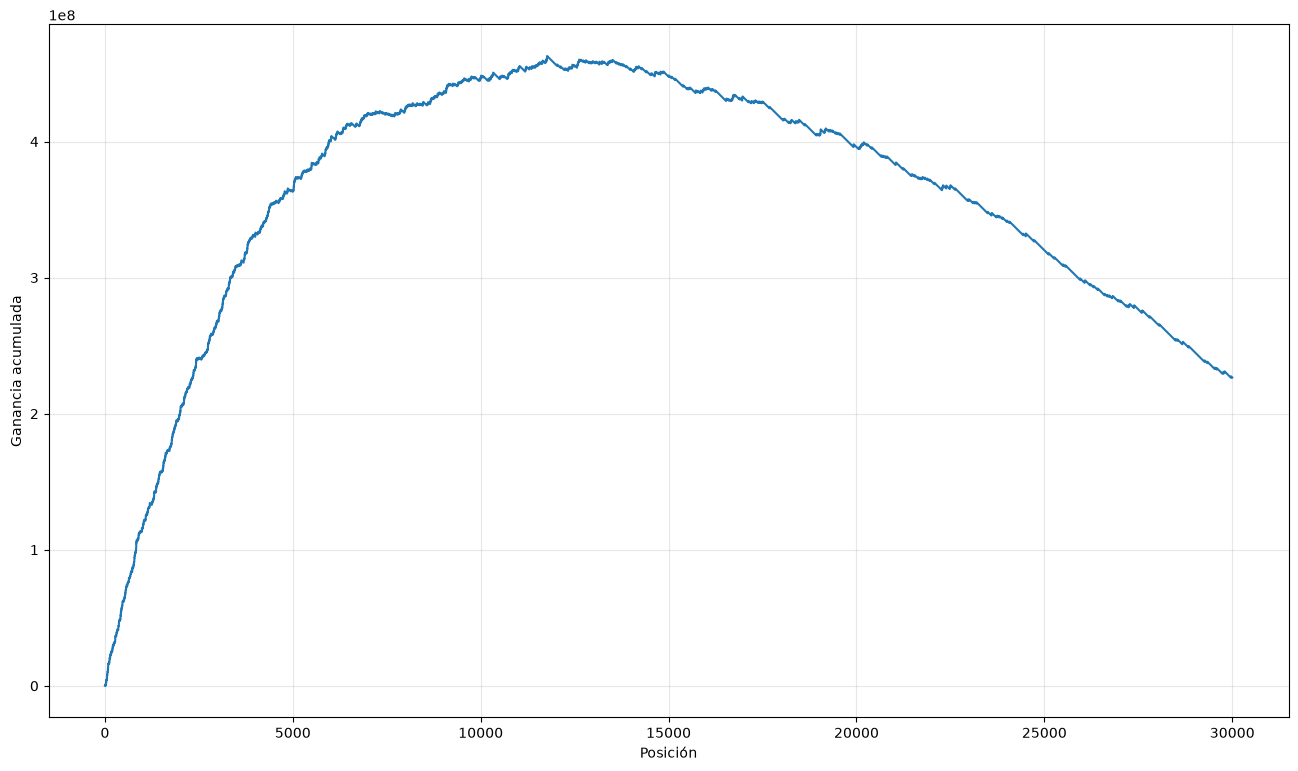

In [34]:
tb_prediccion = tb_prediccion.sort_values("prob", ascending=False).reset_index(drop=True)
tb_prediccion["gan"] = np.where(
    tb_prediccion["ternaria"].eq("BAJA+2"),
    1_072_500,
    -27_500,
)
tb_prediccion["ganancia_acumulada"] = tb_prediccion["gan"].cumsum()
tb_prediccion["pos"] = np.arange(1, len(tb_prediccion) + 1)

amostrar = 30_000
datos_plot = tb_prediccion.loc[tb_prediccion["pos"] <= amostrar]

plt.figure(figsize=(16, 9))
plt.plot(datos_plot["pos"], datos_plot["ganancia_acumulada"])
plt.xlabel("Posición")
plt.ylabel("Ganancia acumulada")
plt.grid(alpha=0.3)
plt.show()

## Ganancia bajo distintos cortes

In [35]:
resultados_cortes = []

for envios in PARAM["cortes"]:
    ganancia = tb_prediccion.iloc[:envios]["gan"].sum()
    resultados_cortes.append({
        "envios": envios,
        "ganancia": ganancia,
    })
    print(f"{envios}	{ganancia:.0f}")

resultados_cortes_df = pd.DataFrame(resultados_cortes)
resultados_cortes_df

9000	435600000
9500	443850000
10000	446600000
10500	446050000
11000	452100000
11500	455950000
12000	456500000
12500	455950000
13000	458700000
13500	459250000
14000	453200000
14500	449350000
15000	447700000


,envios,ganancia
0,9000,435600000
1,9500,443850000
2,10000,446600000
3,10500,446050000
4,11000,452100000
5,11500,455950000
6,12000,456500000
7,12500,455950000
8,13000,458700000
9,13500,459250000


In [36]:
with open(os.path.join(EXPERIMENT_URL, "PARAM.yml"), "w", encoding="utf-8") as archivo:
    yaml.safe_dump(PARAM, archivo, sort_keys=False, allow_unicode=True)

## Segunda BO

In [37]:
experiment_name = experimento_segunda
EXPERIMENT_URL = os.path.join(EXP_URL, experiment_name)
PARAM["experimento"] = experiment_name
PARAM["out"]["lgbm"] = {}
PARAM["dataset"] = os.path.basename(DATA_LAGS_FRAC_URL)

modelos_iniciales = modelos_iniciales_segunda
puntos_iniciales_bo = puntos_iniciales_segunda
PARAM["hyperparametertuning"]["ids_modelos_previos"] = [
    int(i) for i in modelos_iniciales["id_validacion"]
]

print("Espacio común definitivo:", rangos_bo)
print("Inicializaciones anteriores:", len(puntos_iniciales_bo))
print("Inicializaciones aleatorias:",
      PARAM["hyperparametertuning"]["n_startup_trials"] - len(puntos_iniciales_bo))
modelos_iniciales

Espacio común definitivo: {'num_iterations': (400, 2000), 'num_leaves': (256, 2048), 'feature_fraction': (0.1, 0.35), 'min_sum_hessian_in_leaf': (0.0001, 0.1), 'learning_rate': (0.005, 0.025), 'min_data_in_leaf': (100, 1000), 'scale_pos_weight': (0.5, 1.0)}
Inicializaciones anteriores: 10
Inicializaciones aleatorias: 40


,id_validacion,ganancia,seeds,dataset,cantidad_registros_totales,cantidad_registros_entrenamiento,cantidad_registros_validacion,meses_entrenamiento,meses_validacion,columnas_excluidas,benchmark_original
29,30,474897500.0,NaN,competencia_01_ternaria_lags.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090643
38,39,474831500.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lf_k6_perdida4.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_123618
50,51,474831500.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lf_k6_perdida4.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090149
43,44,474831500.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lf_k6_perdida4.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090149
40,41,474281500.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lags.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_114539
42,43,473517000.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lf_k6_perdida4.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090643
31,32,473517000.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lf_k6_perdida4.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090643
27,28,473357500.0,NaN,competencia_01_ternaria_lf_k6_perdida4.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090149
37,38,472384000.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lags.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_123618
44,45,472384000.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lags.csv,983061,326184,164114,"202103,202104",202106.0,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090149


## Lectura del segundo dataset

In [38]:
# Libero los datos y el modelo de la primera BO antes de cargar el otro dataset.
del df, df_completo, dataset_train_cpu, dataset_final_cpu, dfuture_cpu
del X_train_bo, y_train_bo, X_validate_bo, y_validate_bo
del dtrain, dvalidate, dtrain_final, modelo_final, arboles_df, splits_df
gc.collect()

2702

In [39]:
# cudf no pandas -> GPU
df = cudf.read_csv(
    DATA_LAGS_FRAC_URL,
    dtype={'numero_de_cliente': 'int32', 'foto_mes': 'int32'}
)

In [40]:
df.head()

,numero_de_cliente,foto_mes,active_quarter,cliente_vip,internet,cliente_edad,cliente_antiguedad,mrentabilidad,mrentabilidad_annual,mcomisiones,...,Visa_madelantodolares_delta_lag_pond2,Visa_fultimo_cierre_delta_lag_pond2,Visa_mpagado_delta_lag_pond2,Visa_mpagospesos_delta_lag_pond2,Visa_mpagosdolares_delta_lag_pond2,Visa_fechaalta_delta_lag_pond2,Visa_mconsumototal_delta_lag_pond2,Visa_cconsumos_delta_lag_pond2,Visa_cadelantosefectivo_delta_lag_pond2,Visa_mpagominimo_delta_lag_pond2
0,12159854,202103,1,0,0,56,134,688.41,26701.84,98.82,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,12159854,202104,1,0,0,56,135,1622.57,27663.64,931.59,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,12159854,202105,1,0,0,56,136,1987.98,28738.37,934.07,...,0.0,4.0,0.0,1.818989404e-12,0.0,61.0,0.0,0.0,0.0,0.0
3,12159854,202106,1,0,0,56,137,2580.75,29494.76,915.19,...,0.0,-1.714285714,0.0,1.818989404e-12,0.0,69.57142857,-1.818989404e-12,0.0,0.0,-2.273736754e-13
4,12159854,202107,1,0,0,56,138,2686.85,29431.10,688.94,...,0.0,-0.820512821,0.0,1.818989404e-12,0.0,75.20512821,-1.818989404e-12,0.0,0.0,-2.273736754e-13


In [41]:
cudf.crosstab(df['ternaria'].fillna('NA'), df['foto_mes'])

foto_mes,202103,202104,202105,202106,202107,202108
ternaria,,,,,,
BAJA+1,1019,964,1143,874,1103,0
BAJA+2,960,1139,870,1098,0,0
NA,0,0,0,0,163245,164647
continua,160921,161181,161755,162142,0,0


In [42]:
df_completo = df.copy()

## Preprocesamiento

In [43]:
dataset_train_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["train"])]
    .to_pandas()
    .reset_index(drop=True)
)

# Partición estratificada 70/30, equivalente a fold 1 y fold 2 en z495.
indices_fold_1, indices_fold_2 = train_test_split(
    np.arange(len(dataset_train_cpu)),
    train_size=PARAM["training_pct"] / 100,
    stratify=dataset_train_cpu["ternaria"],
    random_state=PARAM["semilla_primigenia"],
)

dataset_train_cpu["fold"] = np.int8(2)
dataset_train_cpu.loc[indices_fold_1, "fold"] = np.int8(1)

# BAJA+1 y BAJA+2 forman la clase positiva, igual que en el R.
dataset_train_cpu["clase01"] = (
    dataset_train_cpu["ternaria"].isin(["BAJA+1", "BAJA+2"])
    .astype(np.int8)
)

rng = np.random.default_rng(PARAM["semilla_primigenia"])
dataset_train_cpu["azar"] = rng.random(len(dataset_train_cpu))
dataset_train_cpu["training"] = (
    dataset_train_cpu["fold"].eq(1)
    & (
        (dataset_train_cpu["azar"] <= PARAM["trainingstrategy"]["undersampling"])
        | dataset_train_cpu["ternaria"].isin(["BAJA+1", "BAJA+2"])
    )
).astype(np.int8)

columnas_excluidas = {
    "ternaria",
    "ternaria_lag1",
    "ternaria_lag2",
    "clase01",
    "fold",
    "azar",
    "training",
    "cprestamos_personales",
    "cprestamos_personales_lag1",
    "cprestamos_personales_delta1",
    "cprestamos_personales_lag2",
    "cprestamos_personales_delta2",
    "cprestamos_personales_lag_pond",
    "cprestamos_personales_delta_lag_pond",
    "cprestamos_personales_lag_pond2",
    "cprestamos_personales_delta_lag_pond2",
    "mprestamos_personales",
    "mprestamos_personales_lag1",
    "mprestamos_personales_delta1",
    "mprestamos_personales_lag2",
    "mprestamos_personales_delta2",
    "mprestamos_personales_lag_pond",
    "mprestamos_personales_delta_lag_pond",
    "mprestamos_personales_lag_pond2",
    "mprestamos_personales_delta_lag_pond2",
}

campos_buenos = [
    columna
    for columna in dataset_train_cpu.columns
    if columna not in columnas_excluidas
]

mask_training = dataset_train_cpu["training"].eq(1)
X_train_bo = dataset_train_cpu.loc[mask_training, campos_buenos]
y_train_bo = dataset_train_cpu.loc[mask_training, "clase01"]

# Replica literalmente z495: validation contiene todas las filas con training == 0.
mask_validation = dataset_train_cpu["training"].eq(0)
X_validate_bo = dataset_train_cpu.loc[mask_validation, campos_buenos]
y_validate_bo = dataset_train_cpu.loc[mask_validation, "clase01"]

dtrain = lgb.Dataset(
    data=X_train_bo,
    label=y_train_bo,
    feature_name=campos_buenos,
    free_raw_data=False,
)

dvalidate = lgb.Dataset(
    data=X_validate_bo,
    label=y_validate_bo,
    feature_name=campos_buenos,
    free_raw_data=False,
)

print("Filas para training:", len(X_train_bo))
print("Filas para validation:", len(X_validate_bo))
print("Columnas:", len(campos_buenos))
dataset_train_cpu.groupby(["fold", "ternaria", "training"]).size()

Filas para training: 25373
Filas para validation: 300811
Columnas: 752


fold  ternaria  training
1     BAJA+1    1             1388
      BAJA+2    1             1469
      continua  0           202955
                1            22516
2     BAJA+1    0              595
      BAJA+2    0              630
      continua  0            96631
dtype: int64

In [44]:
ganancia_validate_bo = np.where(
    dataset_train_cpu.loc[mask_validation, "ternaria"].eq("BAJA+2"),
    1_072_500,
    -27_500,
)


def estimar_ganancia_lightgbm(parametros_variables):
    parametros_completos = {
        **PARAM["lgbm"]["param_fijos"],
        **parametros_variables,
    }

    num_boost_round = int(
        parametros_completos.pop("num_iterations")
    )

    modelo = lgb.train(
        params=parametros_completos,
        train_set=dtrain,
        num_boost_round=num_boost_round,
    )

    prediccion = modelo.predict(X_validate_bo)
    orden = np.argsort(-prediccion)

    ganancia_acumulada = np.cumsum(
        ganancia_validate_bo[orden]
    )

    return float(ganancia_acumulada.max())

## Estudio Optuna y reanudación

In [45]:
os.makedirs(EXPERIMENT_URL, exist_ok=True)

n_startup_trials = PARAM["hyperparametertuning"]["n_startup_trials"]
n_trials_total = PARAM["hyperparametertuning"]["iteraciones"]

sampler = GPSampler(
    seed=PARAM["semilla_primigenia"],
    n_startup_trials=n_startup_trials,
    deterministic_objective=False,
)

study_db_url = os.path.join(EXPERIMENT_URL, "optuna_study.db")
storage_url = f"sqlite:///{study_db_url}"

study = optuna.create_study(
    study_name=experiment_name,
    direction="maximize",
    sampler=sampler,
    storage=storage_url,
    load_if_exists=True,
)

# Como en z999: solo al crear el estudio; conserva HP repetidos.
if not study.trials:
    for punto in puntos_iniciales_bo:
        study.enqueue_trial(punto)

/tmp/ipykernel_380786/1002810896.py:6: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler = GPSampler(
[I 2026-10-09 01:06:23,012] Using an existing study with name 'LAG-026' instead of creating a new one.


In [46]:
trials_completos = sum(
    trial.state == TrialState.COMPLETE
    for trial in study.trials
)
trials_restantes = max(0, n_trials_total - trials_completos)

print("Trials completos:", trials_completos)
print("Trials restantes:", trials_restantes)

if trials_restantes > 0:
    study.optimize(
        objective,
        n_trials=trials_restantes,
        show_progress_bar=True,
    )
else:
    print("c'est fini")

Trials completos: 0
Trials restantes: 200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-10-09 01:06:44,865] Trial 0 finished with value: 0.12120502091074181 and parameters: {'num_iterations': 1067, 'num_leaves': 2048, 'feature_fraction': 0.35, 'min_sum_hessian_in_leaf': 0.0001, 'learning_rate': 0.00675493259696748, 'min_data_in_leaf': 168, 'scale_pos_weight': 0.5}. Best is trial 0 with value: 0.12120502091074181.
[I 2026-10-09 01:06:51,896] Trial 1 finished with value: 0.11759674847723686 and parameters: {'num_iterations': 400, 'num_leaves': 256, 'feature_fraction': 0.239049018582973, 'min_sum_hessian_in_leaf': 0.1, 'learning_rate': 0.0152796385349906, 'min_data_in_leaf': 137, 'scale_pos_weight': 0.5}. Best is trial 0 with value: 0.12120502091074181.
[I 2026-10-09 01:06:58,894] Trial 2 finished with value: 0.11759674847723686 and parameters: {'num_iterations': 400, 'num_leaves': 256, 'feature_fraction': 0.239049018582973, 'min_sum_hessian_in_leaf': 0.1, 'learning_rate': 0.0152796385349906, 'min_data_in_leaf': 137, 'scale_pos_weight': 0.5}. Best is trial 0 with val

In [47]:
tb_bayesiana = study.trials_dataframe()
tb_bayesiana["iter"] = np.arange(1, len(tb_bayesiana) + 1)
tb_bayesiana = (
    tb_bayesiana
    .sort_values("value", ascending=False, na_position="last")
    .reset_index(drop=True)
)
tb_bayesiana.to_csv(
    os.path.join(EXPERIMENT_URL, "BO_log.txt"),
    sep="	",
    index=False,
)

PARAM["out"]["lgbm"]["mejores_hiperparametros"] = dict(study.best_trial.params)
PARAM["out"]["lgbm"]["y"] = float(study.best_value)

with open(os.path.join(EXPERIMENT_URL, "PARAM.yml"), "w", encoding="utf-8") as archivo:
    yaml.safe_dump(PARAM, archivo, sort_keys=False, allow_unicode=True)

print(PARAM["out"]["lgbm"]["mejores_hiperparametros"])
print("Mejor Average Precision:", PARAM["out"]["lgbm"]["y"])
tb_bayesiana.head()

{'num_iterations': 2000, 'num_leaves': 256, 'feature_fraction': 0.35, 'min_sum_hessian_in_leaf': 0.09999999999999998, 'learning_rate': 0.005000000000000002, 'min_data_in_leaf': 100, 'scale_pos_weight': 1.0}
Mejor Average Precision: 0.1279298217984689


,number,value,datetime_start,datetime_complete,duration,params_feature_fraction,params_learning_rate,params_min_data_in_leaf,params_min_sum_hessian_in_leaf,params_num_iterations,params_num_leaves,params_scale_pos_weight,system_attrs_fixed_params,system_attrs_gp:relative_params:0,state,iter
0,71,0.127930,2026-10-09 01:30:34.804028,2026-10-09 01:31:15.113593,0 days 00:00:40.309565,0.35,0.005000,100,0.1000,2000,256,1.0,NaN,"{""feature_fraction"": 0.35, ""learning_rate"": 0....",COMPLETE,72
1,80,0.127930,2026-10-09 01:34:16.392865,2026-10-09 01:34:57.668418,0 days 00:00:41.275553,0.35,0.005000,100,0.1000,2000,946,1.0,NaN,"{""feature_fraction"": 0.35, ""learning_rate"": 0....",COMPLETE,81
2,119,0.127930,2026-10-09 01:50:48.057953,2026-10-09 01:51:30.350504,0 days 00:00:42.292551,0.35,0.005000,100,0.1000,2000,2048,1.0,NaN,"{""feature_fraction"": 0.35, ""learning_rate"": 0....",COMPLETE,120
3,53,0.127893,2026-10-09 01:21:29.247767,2026-10-09 01:21:58.574535,0 days 00:00:29.326768,0.35,0.008483,100,0.0001,1417,256,1.0,NaN,"{""feature_fraction"": 0.35, ""learning_rate"": 0....",COMPLETE,54
4,83,0.127816,2026-10-09 01:35:49.696536,2026-10-09 01:36:08.977153,0 days 00:00:19.280617,0.35,0.010694,100,0.1000,896,2048,1.0,NaN,"{""feature_fraction"": 0.35, ""learning_rate"": 0....",COMPLETE,84


## Producción: segunda BO

In [48]:
dataset_final_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["train_final"])]
    .to_pandas()
    .reset_index(drop=True)
)
dataset_final_cpu["clase01"] = (
    dataset_final_cpu["ternaria"].isin(["BAJA+1", "BAJA+2"])
    .astype(np.int8)
)

dataset_final_cpu.groupby("ternaria").size()

ternaria
BAJA+1        1983
BAJA+2        2099
continua    322102
dtype: int64

In [49]:
dataset_final_cpu.clase01.value_counts()

clase01
0    322102
1      4082
Name: count, dtype: int64

In [50]:
param_final = {
    **PARAM["lgbm"]["param_fijos"],
    **PARAM["out"]["lgbm"]["mejores_hiperparametros"],
}

num_boost_round_final = int(param_final.pop("num_iterations"))
param_final["min_data_in_leaf"] = round(
    param_final["min_data_in_leaf"] / PARAM["trainingstrategy"]["undersampling"]
)
param_final

dtrain_final = lgb.Dataset(
    data=dataset_final_cpu[campos_buenos],
    label=dataset_final_cpu["clase01"],
    feature_name=campos_buenos,
)

modelo_final = lgb.train(
    params=param_final,
    train_set=dtrain_final,
    num_boost_round=num_boost_round_final,
)

In [51]:
arboles_df = modelo_final.trees_to_dataframe()
splits_df = arboles_df.loc[arboles_df["split_feature"].notna()]

tb_importancia = (
    splits_df
    .groupby("split_feature", as_index=False)
    .agg(
        Gain=("split_gain", "sum"),
        Cover=("count", "sum"),
        Frequency=("split_feature", "size"),
    )
    .rename(columns={"split_feature": "Feature"})
)

for columna in ["Gain", "Cover", "Frequency"]:
    total = tb_importancia[columna].sum()
    if total > 0:
        tb_importancia[columna] = tb_importancia[columna] / total

tb_importancia = tb_importancia.sort_values("Gain", ascending=False)
tb_importancia.to_csv(
    os.path.join(EXPERIMENT_URL, "impo.txt"),
    sep="\t",
    index=False,
)
modelo_final.save_model(os.path.join(EXPERIMENT_URL, "modelo.txt"))

tb_importancia.head(20)

,Feature,Gain,Cover,Frequency
292,ctrx_quarter,0.043905,0.014107,0.015448
311,mcaja_ahorro,0.039030,0.010876,0.017839
375,mpasivos_margen,0.033954,0.010381,0.015393
378,mpayroll,0.031997,0.014864,0.009357
350,mcuentas_saldo,0.031683,0.017925,0.016627
229,cpayroll_trx,0.027831,0.009459,0.003797
405,mtarjeta_visa_consumo,0.019823,0.007368,0.013118
394,mrentabilidad_annual,0.019560,0.016216,0.015927
121,Visa_msaldopesos,0.018630,0.009133,0.015310
308,mautoservicio,0.017925,0.009327,0.012507


In [52]:
dfuture_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["future"])]
    .to_pandas()
    .reset_index(drop=True)
)

prediccion = modelo_final.predict(dfuture_cpu[campos_buenos])

tb_prediccion = dfuture_cpu[["numero_de_cliente", "foto_mes", "ternaria"]].copy()
tb_prediccion["prob"] = prediccion
tb_prediccion[["numero_de_cliente", "foto_mes", "prob"]].to_csv(
    os.path.join(EXPERIMENT_URL, "prediccion.txt"),
    sep="\t",
    index=False,
)

tb_prediccion.head()

,numero_de_cliente,foto_mes,ternaria,prob
0,12159854,202106,continua,0.000417
1,12159858,202106,continua,0.003471
2,12160484,202106,continua,0.001108
3,12160591,202106,continua,0.001025
4,12160747,202106,continua,0.005608


In [53]:
with open(os.path.join(EXPERIMENT_URL, "PARAM.yml"), "w", encoding="utf-8") as archivo:
    yaml.safe_dump(PARAM, archivo, sort_keys=False, allow_unicode=True)